# Ch 20·22 부록 — 사전학습량과 perplexity: 더 돌리면 얼마나 내려가나 (이슈 #19)

본편 Ch 20(영어)·Ch 22(한국어)는 small BERT 를 **2 epoch** 만 MLM 사전학습해서 perplexity 가 높았습니다 (영어 ~1,245, 한국어 ~1,918). 짧은 데모 학습의 정직한 반영이지만, *더 돌리면 얼마나 내려가는지* 는 한 점만 봐선 알 수 없습니다.

이 부록은 같은 small BERT(hidden=256·L=4)를 **2 → 16 epoch 으로 길게 학습** 하며, 체크포인트마다 eval perplexity 를 기록해 곡선으로 봅니다. 학습을 한 번만 돌리고 `eval_strategy="steps"` 로 중간 perplexity 를 모으므로 효율적입니다.

> 영어(wikitext-103)·한국어(ko-wiki) 두 곡선을 epoch 축에서 비교. small 모델이라 T4 에서 가볍습니다.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings; warnings.filterwarnings("ignore")
import math, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, torch
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, BertConfig, BertForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"; plt.rcParams["axes.unicode_minus"] = False
print(f"CUDA: {torch.cuda.is_available()}")

CUDA: True


## 1. 공통 유틸 — 블록화 / small BERT / 학습+perplexity 곡선

본편 Ch 20·22 와 같은 파이프라인: `add_special_tokens=False` 토큰화 → `group_texts`(128 블록) → MLM collator. `train_curve` 는 `eval_strategy="steps"` 로 중간 perplexity 를 모아 곡선을 돌려줍니다 (epoch=2 데모점 포함).

In [3]:
BLOCK_SIZE = 128; EPOCHS = 16; SEED = 42

def prep_blocks(text_ds, tokenizer):
    tok = text_ds.map(lambda e: tokenizer(e["text"], add_special_tokens=False, truncation=False),
                      batched=True, remove_columns=text_ds.column_names)
    def group(ex):
        concat = {k: sum(ex[k], []) for k in ex.keys()}
        total = (len(concat["input_ids"]) // BLOCK_SIZE) * BLOCK_SIZE
        return {k: [t[i:i+BLOCK_SIZE] for i in range(0, total, BLOCK_SIZE)] for k, t in concat.items()}
    return tok.map(group, batched=True)

def build_small_bert(tokenizer):
    cfg = BertConfig(vocab_size=tokenizer.vocab_size, hidden_size=256, num_hidden_layers=4,
                     num_attention_heads=4, intermediate_size=1024,
                     max_position_embeddings=BLOCK_SIZE, pad_token_id=tokenizer.pad_token_id)
    return BertForMaskedLM(cfg)

def train_curve(tokenizer, lm_train, lm_eval, label):
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = build_small_bert(tokenizer)
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
    spe = max(1, len(lm_train) // 32)   # steps per epoch
    args = TrainingArguments(output_dir=f"./curve_{label}", num_train_epochs=EPOCHS,
        per_device_train_batch_size=32, per_device_eval_batch_size=64, learning_rate=5e-4,
        weight_decay=0.01, warmup_ratio=0.06, fp16=torch.cuda.is_available(),
        eval_strategy="steps", eval_steps=spe, logging_steps=spe, save_strategy="no",
        report_to="none", seed=SEED)
    tr = Trainer(model=model, args=args, train_dataset=lm_train, eval_dataset=lm_eval,
                 data_collator=collator, processing_class=tokenizer)
    tr.train()
    curve = [(e["step"]/spe, math.exp(e["eval_loss"])) for e in tr.state.log_history if "eval_loss" in e]
    del model, tr; torch.cuda.empty_cache()
    return curve   # [(epoch, perplexity), ...]
print("유틸 준비 완료")

유틸 준비 완료


## 2. 영어 — wikitext-103, small BERT MLM 16 epoch

In [4]:
raw_tr = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="train")
raw_ev = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="validation")
good = lambda ex: 50 <= len(ex["text"].strip()) <= 2000
tr_txt = raw_tr.filter(good).shuffle(seed=SEED).select(range(5000))
ev_txt = raw_ev.filter(good).shuffle(seed=SEED).select(range(500))
tok_en = AutoTokenizer.from_pretrained("bert-base-uncased")
lm_tr_en = prep_blocks(tr_txt, tok_en); lm_ev_en = prep_blocks(ev_txt, tok_en)
print(f"EN blocks — train {len(lm_tr_en)}, eval {len(lm_ev_en)}, vocab {tok_en.vocab_size}")
curve_en = train_curve(tok_en, lm_tr_en, lm_ev_en, "en")
print("EN (epoch, ppl):", [(round(e,1), round(p,1)) for e,p in curve_en])

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

EN blocks — train 5352, eval 535, vocab 30522


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
167,8.343126,7.316822
334,7.136370,7.067557
501,6.943620,6.929424
668,6.833370,6.824947
835,6.789655,6.833147
1002,6.719472,6.781228
1169,6.674789,6.762815
1336,6.624700,6.686670
1503,6.612422,6.679445
1670,6.578442,6.613037


EN (epoch, ppl): [(1.0, 1505.4), (2.0, 1173.3), (3.0, 1021.9), (4.0, 920.5), (5.0, 928.1), (6.0, 881.1), (7.0, 865.1), (8.0, 801.6), (9.0, 795.9), (10.0, 744.7), (11.0, 764.1), (12.0, 732.9), (13.0, 713.8), (14.0, 683.9), (15.0, 746.0), (16.0, 701.5), (16.1, 695.7)]


## 3. 한국어 — ko-wiki, small BERT MLM 16 epoch

In [5]:
ds_ko = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train")
def collect_paragraphs(ds, target, min_len=50, max_len=2000):
    out = []
    for ex in ds:
        for para in ex["text"].split("\n\n"):
            para = para.strip()
            if min_len <= len(para) <= max_len:
                out.append(para)
                if len(out) >= target: return out
    return out
paras = collect_paragraphs(ds_ko.shuffle(seed=SEED), target=5500)
tr_ko = Dataset.from_dict({"text": paras[:5000]}); ev_ko = Dataset.from_dict({"text": paras[5000:5500]})
tok_ko = AutoTokenizer.from_pretrained("klue/bert-base")
lm_tr_ko = prep_blocks(tr_ko, tok_ko); lm_ev_ko = prep_blocks(ev_ko, tok_ko)
print(f"KO blocks — train {len(lm_tr_ko)}, eval {len(lm_ev_ko)}, vocab {tok_ko.vocab_size}")
curve_ko = train_curve(tok_ko, lm_tr_ko, lm_ev_ko, "ko")
print("KO (epoch, ppl):", [(round(e,1), round(p,1)) for e,p in curve_ko])

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.ko/train-00000-of-00003.parquet:   0%|          | 0.00/400M [00:00<?, ?B/s]

20231101.ko/train-00001-of-00003.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

20231101.ko/train-00002-of-00003.parquet:   0%|          | 0.00/177M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/647897 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

KO blocks — train 3924, eval 429, vocab 32000


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss
122,8.756508,7.745484
244,7.447496,7.394163
366,7.200142,7.198132
488,7.008172,7.047074
610,6.870811,6.983854
732,6.763340,6.886613
854,6.696243,6.861089
976,6.610327,6.848239
1098,6.533539,6.872924
1220,6.483323,6.752027


KO (epoch, ppl): [(1.0, 2311.1), (2.0, 1626.5), (3.0, 1336.9), (4.0, 1149.5), (5.0, 1079.1), (6.0, 979.1), (7.0, 954.4), (8.0, 942.2), (9.0, 965.8), (10.0, 855.8), (11.0, 861.9), (12.0, 845.9), (13.0, 824.7), (14.0, 817.2), (15.0, 736.7), (16.0, 756.4), (16.1, 708.7)]


## 4. 곡선 — eval perplexity vs 사전학습 epoch

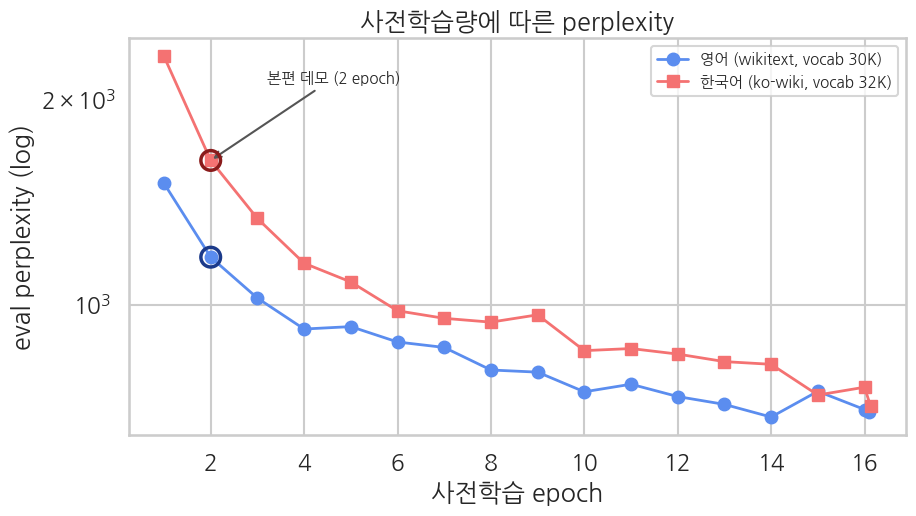

영어: 2 epoch ppl=1173 → 16 epoch ppl=696  (1.7배 감소)
한국어: 2 epoch ppl=1626 → 16 epoch ppl=709  (2.3배 감소)


In [6]:
def at_epoch(curve, ep):
    return min(curve, key=lambda x: abs(x[0]-ep))[1]
en_ep, en_pp = zip(*curve_en); ko_ep, ko_pp = zip(*curve_ko)
sns.set_theme(style="whitegrid", context="talk", font="NanumGothic", rc={"axes.unicode_minus": False})
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(en_ep, en_pp, "o-", color="#5B8DEF", lw=2, label="영어 (wikitext, vocab 30K)")
ax.plot(ko_ep, ko_pp, "s-", color="#F47272", lw=2, label="한국어 (ko-wiki, vocab 32K)")
# 본편 데모점 (2 epoch)
ax.scatter([2],[at_epoch(curve_en,2)], s=200, facecolors="none", edgecolors="#1B3A8A", lw=2.5, zorder=5)
ax.scatter([2],[at_epoch(curve_ko,2)], s=200, facecolors="none", edgecolors="#8A1B1B", lw=2.5, zorder=5)
ax.annotate("본편 데모 (2 epoch)", (2, at_epoch(curve_ko,2)), xytext=(3.2, at_epoch(curve_ko,2)*1.3),
            fontsize=11, arrowprops=dict(arrowstyle="->", color="#555"))
ax.set_yscale("log"); ax.set_xlabel("사전학습 epoch"); ax.set_ylabel("eval perplexity (log)")
ax.set_title("사전학습량에 따른 perplexity")
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

for name, c in [("영어", curve_en), ("한국어", curve_ko)]:
    p2, pf = at_epoch(c,2), c[-1][1]
    print(f"{name}: 2 epoch ppl={p2:.0f} → {EPOCHS} epoch ppl={pf:.0f}  ({p2/pf:.1f}배 감소)")

## 5. 해석

**더 학습하면 perplexity 는 분명히 내려갑니다 — 다만 곧 평탄해집니다.**

| | 2 epoch (본편 데모) | 16 epoch | 감소 |
|---|---|---|---|
| 영어 (wikitext) | 1,173 | 696 | 1.7배 |
| 한국어 (ko-wiki) | 1,626 | 709 | 2.3배 |

곡선을 보면 두 언어 모두 처음 몇 epoch 에서 가파르게 떨어지다가 **epoch 8-10 부터 평탄** 해집니다. 8배 더 돌려도(2→16 epoch) perplexity 는 ~2배 낮아질 뿐이고, 마지막 6 epoch 은 거의 움직이지 않습니다.

**왜 평탄해지나 — 데이터가 병목입니다.** 5,000 텍스트는 small BERT 가 금세 다 외울 만큼 적어, epoch 을 늘리면 train loss 는 계속 떨어져도 *새 패턴* 을 못 봐 eval perplexity 가 saturate 합니다 (overfitting 영역 진입). 잘 학습된 BERT 의 perplexity 가 두 자리-수십 수준인 것과의 큰 격차는 **epoch 이 아니라 데이터·compute 규모** 의 문제입니다 — 원본 BERT 는 수십억 토큰으로 학습했습니다.

**그래서 본편의 높은 perplexity 는 버그가 아닙니다.** "데모용 짧은 학습이라 빈도까지만 익힌 단계" 가 맞고, 더 돌리면 ~2배까지는 내려가지만 그 이상은 *데이터 양* 을 늘려야 합니다. 이는 Ch 21 부록(데이터 스케일링)에서 본 *데이터가 가장 큰 lever* 라는 교훈, 그리고 Ch 21·23 의 사전학습 분류 천장과 같은 뿌리입니다.